In [63]:
#libraries used
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
import seaborn as sns
import numpy as np
from scipy.stats import linregress
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

loading the data and listing all the column names 

In [64]:
# Loading the data
df=pd.read_csv(r"PPR-ALL.csv",encoding='unicode_escape')
# To see the first few top rows, and to check if the data has been read properly
df.head()

,Date of Sale (dd/mm/yyyy),Address,County,Eircode,Price (),Not Full Market Price,VAT Exclusive,Description of Property,Property Size Description
0,01/01/2010,"5 Braemor Drive, Churchtown, Co.Dublin",Dublin,NaN,"343,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN
1,03/01/2010,"134 Ashewood Walk, Summerhill Lane, Portlaoise",Laois,NaN,"185,000.00",No,Yes,New Dwelling house /Apartment,greater than or equal to 38 sq metres and less...
2,04/01/2010,"1 Meadow Avenue, Dundrum, Dublin 14",Dublin,NaN,"438,500.00",No,No,Second-Hand Dwelling house /Apartment,NaN
3,04/01/2010,"1 The Haven, Mornington",Meath,NaN,"400,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN
4,04/01/2010,"11 Melville Heights, Kilkenny",Kilkenny,NaN,"160,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN


In [65]:
# Clean the Price column (just removing non-numbers)
# This handles the Euro symbol and commas
df.iloc[:, 4] = df.iloc[:, 4].astype(str).str.replace(r'[^0-9.]', '', regex=True)
df.iloc[:, 4] = pd.to_numeric(df.iloc[:, 4], errors='coerce')

# Renaming just the basics for graphs
df = df.rename(columns={df.columns[0]: 'Date', df.columns[2]: 'County', df.columns[4]: 'Price'})

# Create the Year column
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Year'] = df['Date'].dt.year

# Dropping rows where Price couldn't be cleaned (headers/empty lines)
df = df.dropna(subset=['Price'])

# Success Check
print(f"Dataset Ready: {len(df)} records loaded.")
print(df[['Date', 'County', 'Price', 'Year']].head())



Dataset Ready: 771768 records loaded.
        Date    County     Price  Year
0 2010-01-01    Dublin  343000.0  2010
1 2010-01-03     Laois  185000.0  2010
2 2010-01-04    Dublin  438500.0  2010
3 2010-01-04     Meath  400000.0  2010
4 2010-01-04  Kilkenny  160000.0  2010


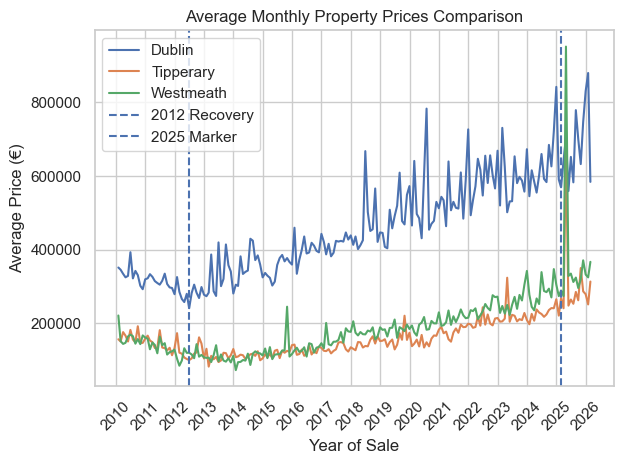

In [66]:
for county in ["Dublin", "Tipperary", "Westmeath"]:
    filtered_df = df[df['County'] == county]
    filtered_df = filtered_df.sort_values("Date")
    filtered_df = filtered_df.set_index("Date")
    
    monthly_price = filtered_df["Price"].resample("M").mean()
    
    plt.plot(monthly_price, label=county)

# Axis formatting
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Reference lines
ax.axvline(x=pd.to_datetime("2012-07-01"), linestyle='--', label='2012 Recovery')
ax.axvline(x=pd.to_datetime("2025-03-01"), linestyle='--', label='2025 Marker')

plt.ylabel("Average Price (€)")
plt.xlabel("Year of Sale")
plt.title("Average Monthly Property Prices Comparison")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.show()

VAT Classification Consistency Across Counties

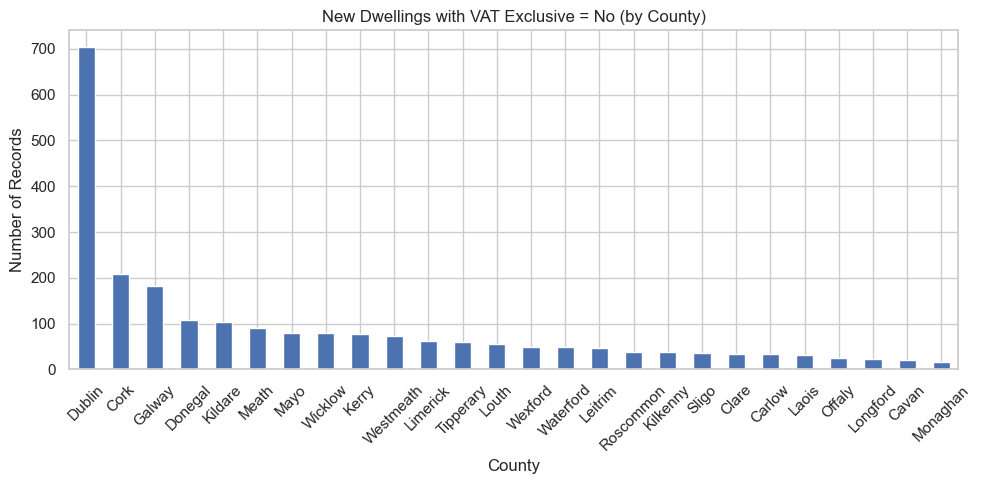

In [67]:
# Filtering for Westmeath
filtered_df = df[df['County'] == "Westmeath"]
filtered_df = filtered_df.sort_values("Date")
filtered_df = filtered_df.set_index("Date")

# Resampling to Monthly mean
filtered_monthly_price = filtered_df["Price"].resample("M").mean()

# Filtering for New Dwellings where VAT Exclusive is "No"
vat_df = df[(df["Description of Property"] == "New Dwelling house /Apartment") & (df["VAT Exclusive"] == "No")]

# Counting records per County to check for reporting consistency
county_count = vat_df["County"].value_counts()

# Generating the bar chart
plt.figure(figsize=(10, 5))
county_count.plot(kind="bar")

plt.title("New Dwellings with VAT Exclusive = No (by County)")
plt.xlabel("County")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [68]:
sales_df=df[((df["Description of Property"]=="New Dwelling house /Apartment") | (df["Description of Property"]=="Second-Hand Dwelling house /Apartment")) & (df["Year"]!=2026)].groupby(["Year","Description of Property"]).size().unstack(fill_value=0)
sales_df.head()

Description of Property,New Dwelling house /Apartment,Second-Hand Dwelling house /Apartment
Year,,
2010,5312,15687
2011,2954,15486
2012,3173,22195
2013,3893,26325
2014,5422,38248


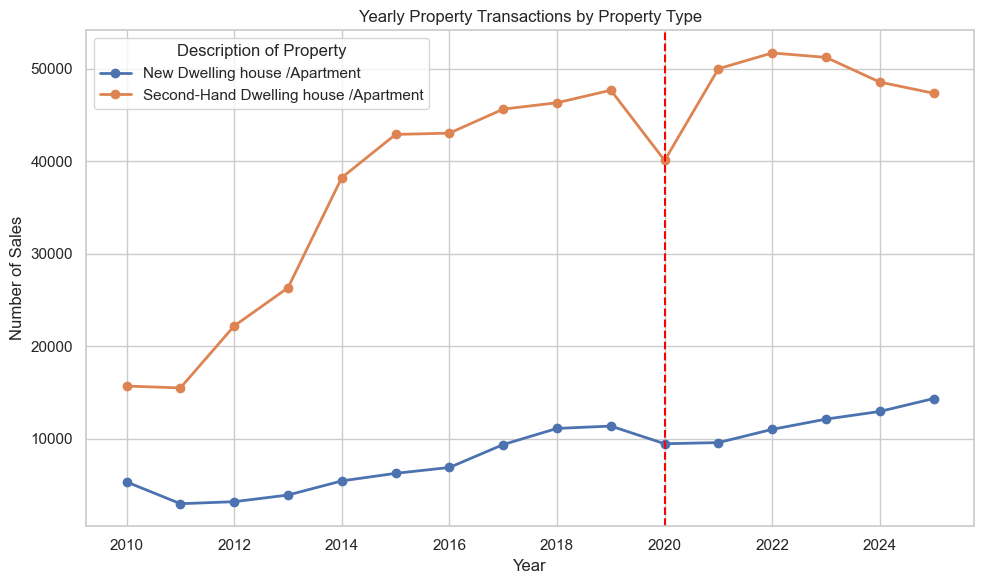

In [69]:
fig, ax = plt.subplots(figsize=(10,6))
sales_df.plot(ax=ax, marker='o', linewidth=2)
ax.set_title("Yearly Property Transactions by Property Type")
ax.axvline(x=2020, color='red', linestyle='--', label="COVID-19 Pandemic Start")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Sales")
ax.grid(True)
plt.tight_layout()
plt.show()

the yearly property transactions based on tyes of properties  shows a genral upward trend a small drop in the year 2020 which was caused by a global pandemic and then the markter stabilized and continued tp go up in the following years.

In [70]:
# Defining Regional Mapping
commuter_counties = ['Kildare', 'Meath', 'Wicklow']

def classify_region(county):
    if county == 'Dublin':
        return 'Dublin'
    elif county in commuter_counties:
        return 'Commuter Belt'
    else:
        return 'Other'

# Applying classification and focusing only on our target regions
df['Region'] = df['County'].apply(classify_region)
df_regions = df[df['Region'] != 'Other'].copy()

# Calculating Annual Median Prices
regional_trends = df_regions.groupby(['Year', 'Region'])['Price'].median().unstack()

# Calculating the 'Dublin Premium' (The Absolute Gap)
regional_trends['Dublin_Premium'] = regional_trends['Dublin'] - regional_trends['Commuter Belt']

# Calculating the Percentage Gap (The Relative Difference)
regional_trends['Gap_Percentage'] = (regional_trends['Dublin_Premium'] / regional_trends['Commuter Belt']) * 100

# Reviewing the initial findings
print("Regional Trend Summary (First 5 Years):")
print(regional_trends.head())

Regional Trend Summary (First 5 Years):
Region Commuter Belt     Dublin Dublin_Premium Gap_Percentage
Year                                                         
2010        223000.0   267500.0        44500.0      19.955157
2011        195000.0  237885.46       42885.46      21.992544
2012        170000.0  202643.17       32643.17      19.201865
2013        165000.0   220000.0        55000.0      33.333333
2014        190000.0   253000.0        63000.0      33.157895


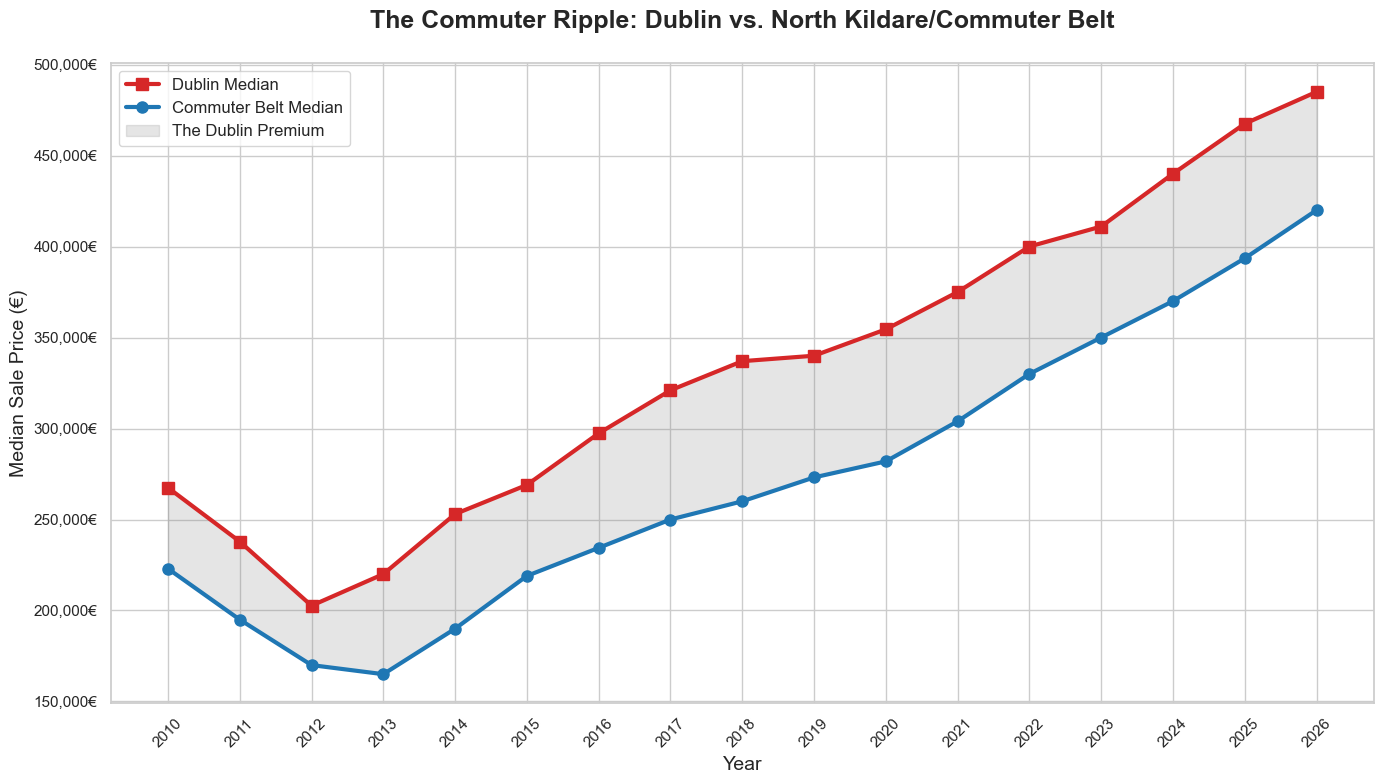

In [71]:
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Ensure the index (Year) and columns (Prices) are explicitly numeric
regional_trends.index = pd.to_numeric(regional_trends.index)
regional_trends['Dublin'] = pd.to_numeric(regional_trends['Dublin'])
regional_trends['Commuter Belt'] = pd.to_numeric(regional_trends['Commuter Belt'])

# Plotting the two main trend lines
plt.plot(regional_trends.index, regional_trends['Dublin'],
         color='#d62728', linewidth=3, label='Dublin Median', marker='s', markersize=8)

plt.plot(regional_trends.index, regional_trends['Commuter Belt'],
         color='#1f77b4', linewidth=3, label='Commuter Belt Median', marker='o', markersize=8)

# Filling the Gap (The "Ripple" Area)
plt.fill_between(regional_trends.index,
                 regional_trends['Commuter Belt'],
                 regional_trends['Dublin'],
                 color='gray', alpha=0.2, label='The Dublin Premium')

# Adding Title and Formatting
plt.title('The Commuter Ripple: Dublin vs. North Kildare/Commuter Belt', fontsize=18, fontweight='bold', pad=25)
plt.ylabel('Median Sale Price (€)', fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.xticks(regional_trends.index, rotation=45)
plt.legend(loc='upper left', frameon=True, fontsize=12)

# Cleaning up Y-axis
plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}€".format(int(x))))

plt.tight_layout()
plt.show()

In [72]:
bubble_counties = ['Dublin', 'Kildare', 'Meath', 'Wicklow']
pivot_growth = df[df['County'].isin(bubble_counties)].groupby(['Year', 'County'])['Price'].median().unstack()

# Normalizing to 2010 (The Baseline Year)
growth_index = (pivot_growth / pivot_growth.loc[2010]) * 100

# Verifying the Growth Index calculation
print("Growth Index (2010 = 100% Baseline) successfully calculated.")
print(growth_index.tail())

Growth Index (2010 = 100% Baseline) successfully calculated.
County      Dublin     Kildare       Meath     Wicklow
Year                                                  
2022     149.53271  150.129963  150.000247  151.938539
2023     153.64486  159.092946  158.695785  157.177783
2024    164.485981  165.834924  167.391422   164.16346
2025    174.766355  177.680277  184.782766  165.909802
2026    181.308411  184.568349  197.391472  176.519382


version 1-  Simple linear regresssion model to predict prices based on location and year of the property.

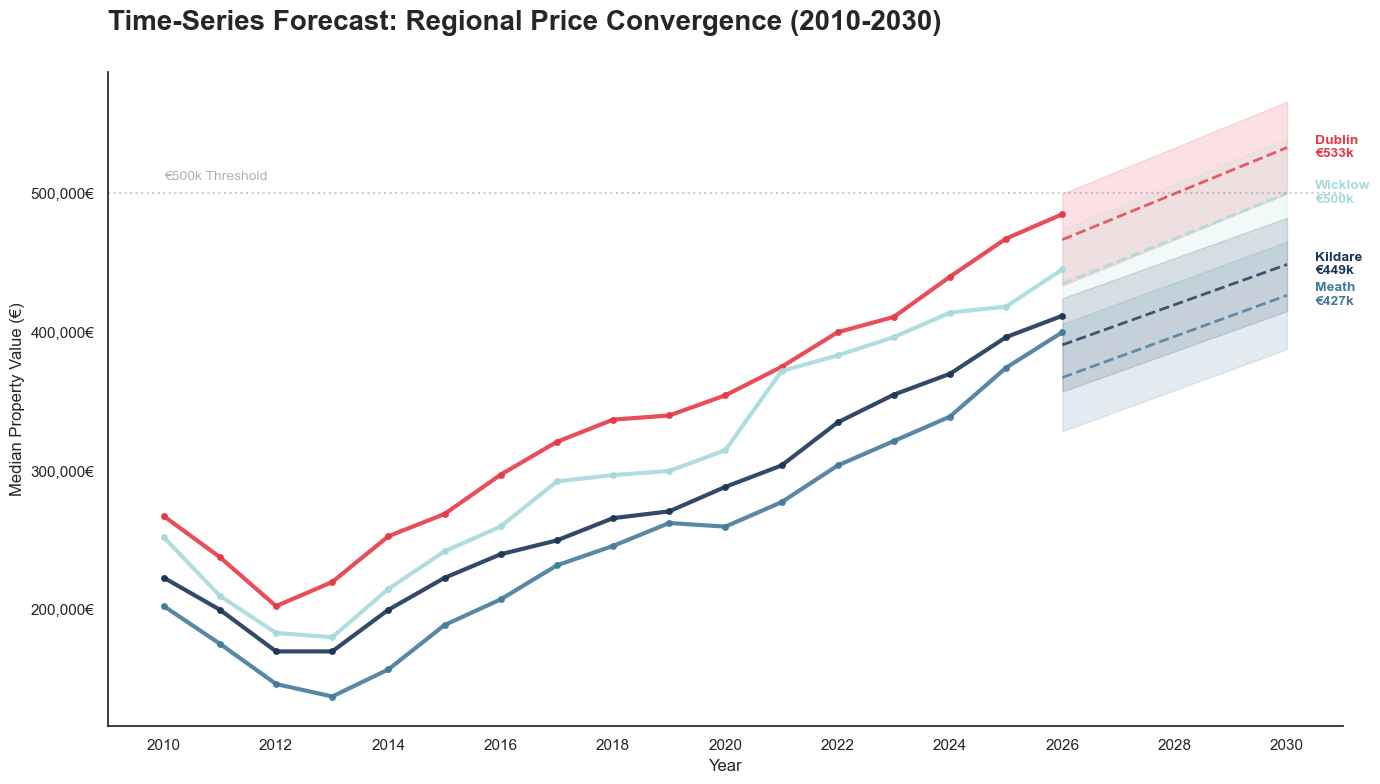

In [73]:
# Defining the Forecast Corridor timeline from 2010 to 2030
forecast_years = np.array(range(2010, 2031))
future_segment = forecast_years[forecast_years >= 2026]

plt.figure(figsize=(14, 8))
sns.set_style("white") # Using a clean 'stock-style' white background

# Color palette
colors = {'Dublin': '#E63946', 'Kildare': '#1D3557', 'Meath': '#457B9D', 'Wicklow': '#A8DADC'}

# Calculating Trends and Uncertainty Bands
for county in bubble_counties:
    # Ensure data is clean and numeric
    y_hist = pivot_growth[county].dropna()
    x_hist = np.array(y_hist.index, dtype=float)
    y_vals = np.array(y_hist.values, dtype=float)

    # Linear Regression for the trend
    slope, intercept, r_value, p_value, std_err = linregress(x_hist, y_vals)

    # Calculate Forecast
    projection = intercept + slope * forecast_years
    future_projection = intercept + slope * future_segment

    # Calculate the 'Uncertainty Ribbon', Standard Error of the Estimate
    residuals = y_vals - (intercept + slope * x_hist)
    res_std = np.std(residuals)

    # Plotting Historical Data
    plt.plot(x_hist, y_vals, color=colors[county], linewidth=3,
             label=f'{county} Actual', marker='o', markersize=4, alpha=0.9)

    # Plotting the Forecast Ribbon
    upper_bound = future_projection + (res_std * 1.5)
    lower_bound = future_projection - (res_std * 1.5)

    plt.fill_between(future_segment, lower_bound, upper_bound,
                     color=colors[county], alpha=0.15)

    # Central Trend Line (Dashed)
    plt.plot(future_segment, future_projection, color=colors[county],
             linestyle='--', linewidth=2, alpha=0.8)

    # Labeling at the end of the Corridor
    plt.text(2030.5, future_projection[-1], f"{county}\n€{future_projection[-1]/1000:.0f}k",
             color=colors[county], fontweight='bold', va='center', fontsize=10)

# Formatting
plt.title('Time-Series Forecast: Regional Price Convergence (2010-2030)',
          fontsize=20, fontweight='bold', loc='left', pad=30)
plt.ylabel('Median Property Value (€)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.xticks(range(2010, 2032, 2))

# Adding a Milestone line for context
plt.axhline(500000, color='gray', linestyle=':', alpha=0.4)
plt.text(2010, 510000, "€500k Threshold", color='gray', alpha=0.6, fontsize=10)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}€".format(int(x))))
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

version 2- Hybrid Time-Series Forecasting Model for Regional Property Price Convergence in the Greater Dublin Area vs commuter belt regions (2010–2030)

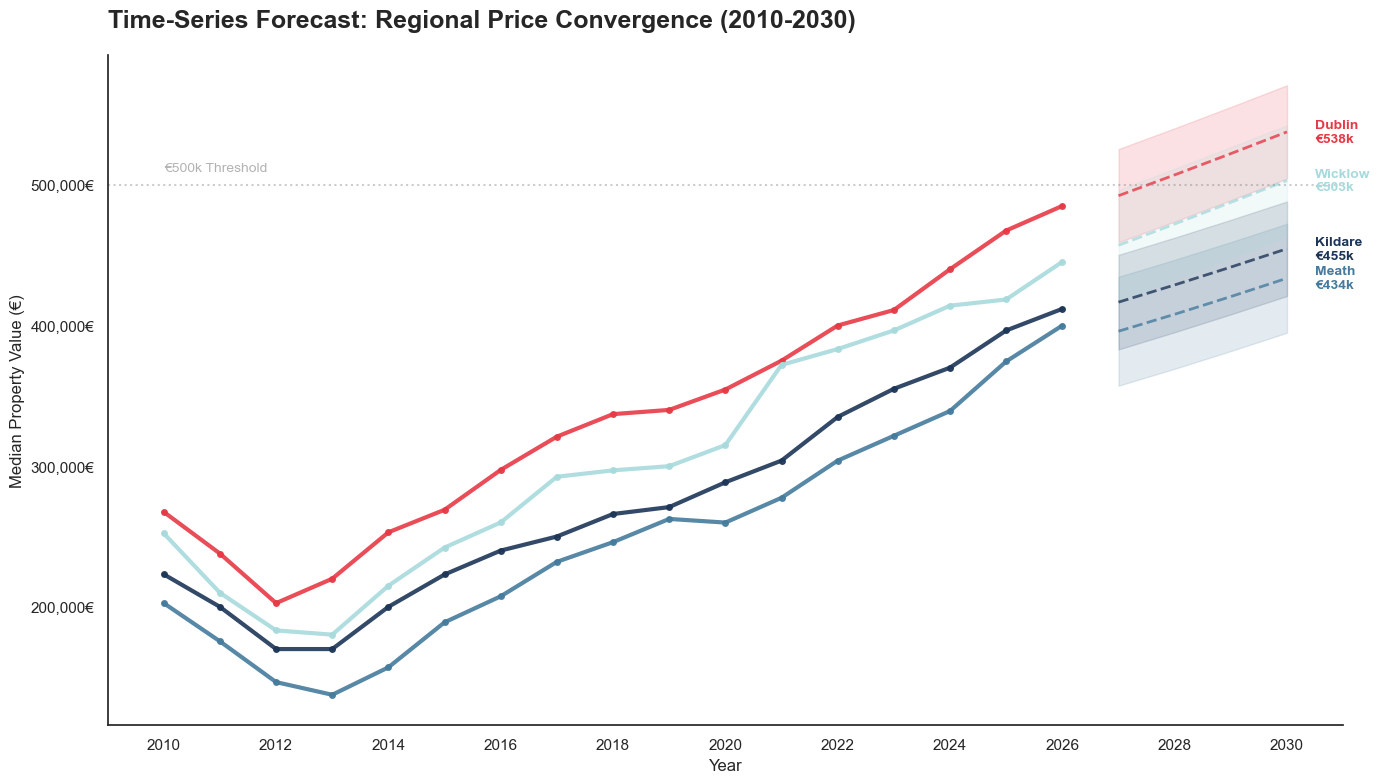

In [74]:
counties = ["Dublin", "Kildare", "Meath", "Wicklow"]
colors   = {"Dublin": "#E63946", "Kildare": "#1D3557", "Meath": "#457B9D", "Wicklow": "#A8DADC"}

filtered      = df[df["County"].isin(counties)]
median_prices = filtered.groupby(["Year", "County"])["Price"].median().unstack()

forecast_years = np.array(range(2010, 2031))
future_segment = forecast_years[forecast_years >= median_prices.index.max() + 1]

plt.figure(figsize=(14, 8))

for county in counties:
    y_hist = median_prices[county].dropna()
    x_hist = np.array(y_hist.index, dtype=float)
    y_vals = np.array(y_hist.values, dtype=float)

    # linear trend
    slope, intercept, _, _, _ = linregress(x_hist, y_vals)

    # exponential smoothing on residuals 
    residuals = y_vals - (intercept + slope * x_hist)
    alpha, smoothed_val = 0.4, residuals[0]
    for r in residuals:
        smoothed_val = alpha * r + (1 - alpha) * smoothed_val

    # forecast = trend + smoothed residual fading out over time
    trend_forecast    = intercept + slope * future_segment
    residual_forecast = np.array([smoothed_val * (0.8 ** (k + 1)) for k in range(len(future_segment))])
    future_projection = trend_forecast + residual_forecast

    # uncertainty band
    res_std     = np.std(residuals)
    upper_bound = future_projection + res_std * 1.5
    lower_bound = future_projection - res_std * 1.5

    # plot actual data
    plt.plot(x_hist, y_vals, color=colors[county], linewidth=3,
             marker="o", markersize=4, alpha=0.9, label=f"{county} Actual")

    # plot forecast ribbon and dashed line
    plt.fill_between(future_segment, lower_bound, upper_bound, color=colors[county], alpha=0.15)
    plt.plot(future_segment, future_projection, color=colors[county], linestyle="--", linewidth=2, alpha=0.8)

    # label at the end
    plt.text(future_segment[-1] + 0.5, future_projection[-1],
             f"{county}\n€{future_projection[-1]/1000:.0f}k",
             color=colors[county], fontweight="bold", va="center", fontsize=10)

plt.title("Time-Series Forecast: Regional Price Convergence (2010-2030)",
          fontsize=18, fontweight="bold", loc="left", pad=20)
plt.ylabel("Median Property Value (€)", fontsize=12)
plt.xlabel("Year", fontsize=12)
plt.xticks(range(2010, 2032, 2))
plt.axhline(500000, color="gray", linestyle=":", alpha=0.4)
plt.text(2010, 510000, "€500k Threshold", color="gray", alpha=0.6, fontsize=10)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: "{:,}€".format(int(x))))
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("convergence_forecast.png", dpi=150, bbox_inches="tight")
plt.show()